# Main Problem:
**customer complaints about late deliveries have spiked in the last quarter.**
> *what is driving the delays and which customer segments are most affected?*




# Data Info

•	**ID**: ID Number of Customers.

•	**Warehouse block**: The Company have big Warehouse which is divided in to block such as A,B,C,D,E.

•	**Mode of shipment**:The Company Ships the products in multiple way such as Ship, Flight and Road.

•	**Customer care calls**: The number of calls made from enquiry for enquiry of the shipment.

•	**Customer rating**: The company has rated from every customer. 1 is the lowest (Worst), 5 is the highest (Best).

•	**Cost of the product**: Cost of the Product in US Dollars.


•	**Prior purchases**: The Number of Prior Purchase.

•	**Product importance**: The company has categorized the product in the various parameter such as low, medium, high.

•	**Gender**: Male and Female.

•	**Discount offered**: Discount offered on that specific product.

•	**Weight in gms:** It is the weight in grams.

•	**Reached on time**: It is the target variable, where 1 Indicates that the product has NOT reached on time and 0 indicates it has reached on time.



# Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
import kagglehub
path = kagglehub.dataset_download("prachi13/customer-analytics")

100%|██████████| 121k/121k [00:00<00:00, 39.8MB/s]

Extracting files...


In [109]:
import os

# List contents of the downloaded dataset directory
dataset_files = os.listdir(path)

csv_file_name = 'Train.csv'

if csv_file_name in dataset_files:
    full_csv_path = os.path.join(path, csv_file_name)
    df = pd.read_csv(full_csv_path)
    print(f"Successfully loaded {csv_file_name}")
else:
    print(f"Expected file {csv_file_name} not found in {path}. Files found: {dataset_files}")

Successfully loaded Train.csv


In [4]:
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [110]:
df.shape

(10999, 12)



---



# Data Cleaning

## Null Values

In [6]:
df.isnull().sum()

,0
ID,0
Warehouse_block,0
Mode_of_Shipment,0
Customer_care_calls,0
Customer_rating,0
Cost_of_the_Product,0
Prior_purchases,0
Product_importance,0
Gender,0
Discount_offered,0


**No Null Values**


---



## Duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

**No Duplicated Values**


---



## Data Types

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [9]:
df.head(1)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1


**All Data Types are Correct**


---



## Outliers

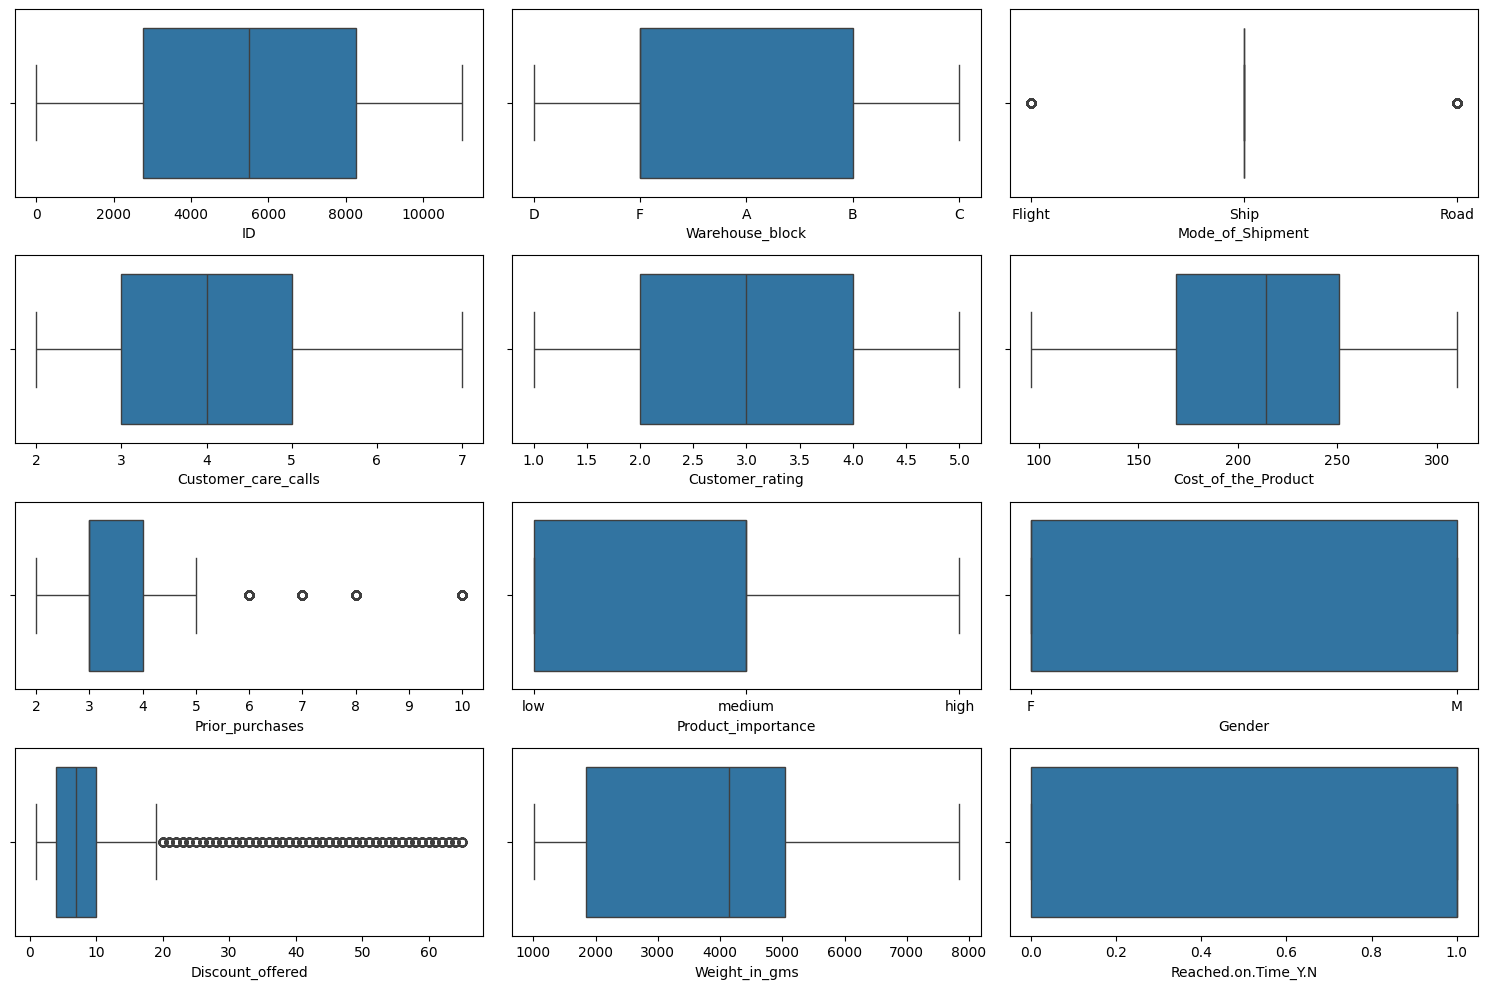

In [24]:
fig, ax = plt.subplots(4, 3, figsize=(15, 10))
ax = ax.flatten()
for i, col in enumerate(df.columns):
    sns.boxplot(x=df[col], ax=ax[i])
plt.tight_layout()
plt.show()

In [26]:
df['Discount_offered'].describe()

,Discount_offered
count,10999.000000
mean,13.373216
std,16.205527
min,1.000000
25%,4.000000
50%,7.000000
75%,10.000000
max,65.000000


**All Values are in normal range**


---



# EDA

### Delay

In [111]:
df.rename(columns={'Reached.on.Time_Y.N':'Delay'},inplace=True)

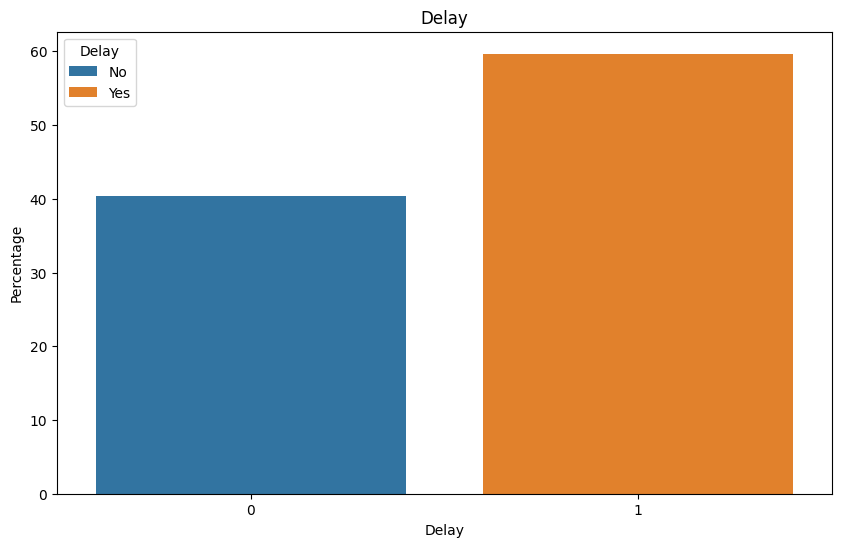

In [112]:

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Delay',stat='percent',hue='Delay')
plt.legend(loc='upper left',title='Delay',labels=['No','Yes'])
plt.title('Delay')
plt.xlabel('Delay')
plt.ylabel('Percentage')
plt.show()

**60% of Shipments Got Delayed!!**



---


### Delay by Type of Shipment

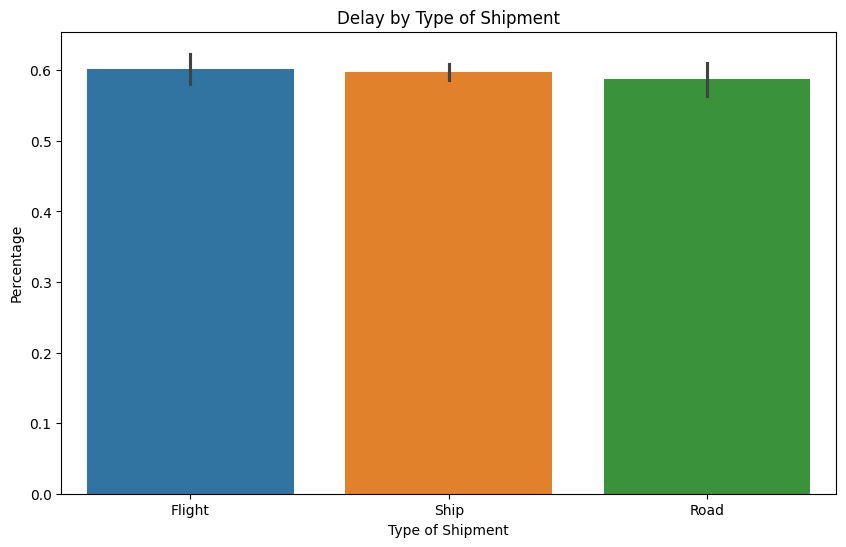

In [63]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Mode_of_Shipment', y='Delay',hue='Mode_of_Shipment')
plt.title('Delay by Type of Shipment')
plt.xlabel('Type of Shipment')
plt.ylabel('Percentage')
plt.show()

**Mode of Shipment Doesnt Seem to affect the delay as all three modes have almost 60% delay**



---

## Discount

Text(0, 0.5, 'Density')

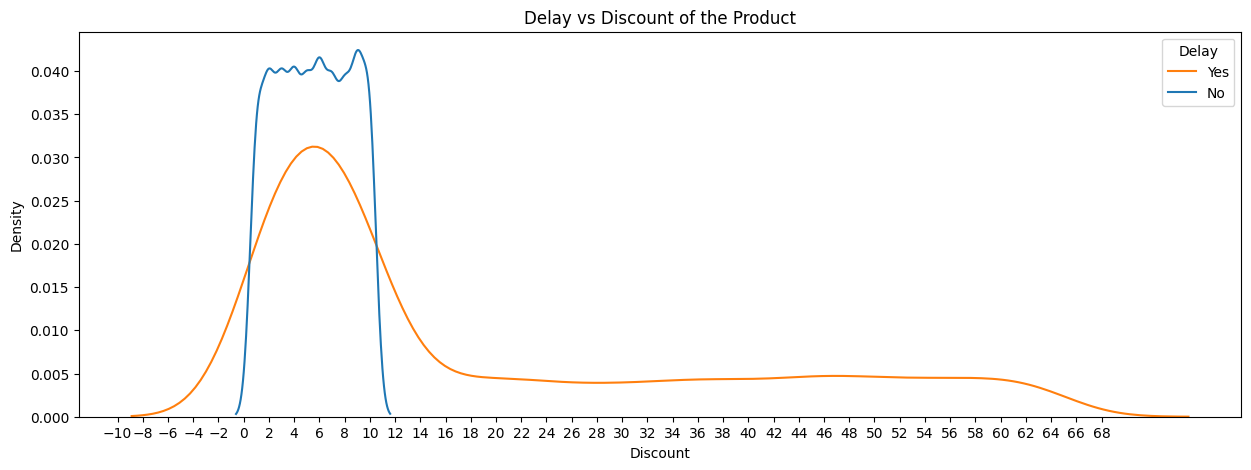

In [205]:
plt.figure(figsize=(15,5))
sns.kdeplot(data=df,x='Discount_offered',hue='Delay')
plt.legend(title='Delay',labels=['Yes','No'])
plt.title('Delay vs Discount of the Product')
plt.xticks(range(-10,70,2))
plt.xlabel('Discount')
plt.ylabel('Density')



---
### **Delay vs Weight**


Text(0, 0.5, 'Discount')

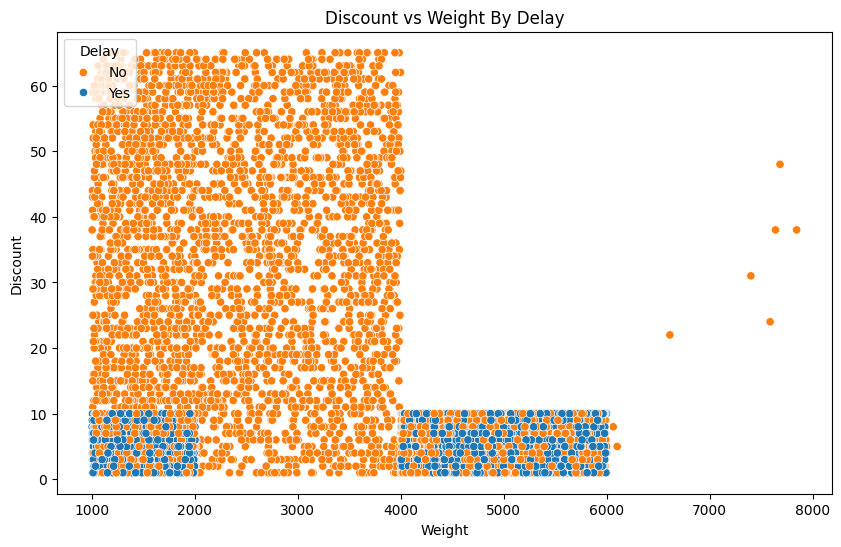

In [114]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Weight_in_gms',y='Discount_offered',data=df,hue='Delay')
plt.legend(loc='upper left',title='Delay',labels=['No','Yes'])

plt.title('Discount vs Weight By Delay')
plt.xlabel('Weight')
plt.ylabel('Discount')



*   **Discount Ranged from 0 to 65% in weight between 1kg and 4kg**
*   **Discount Ranged from 0 to only 10% in weight between 4kg and 6kg**
*   **items heavier than 6k rarely got any discount**
*   **No Delay Shipment Ranged from 1kg to 2kg and then from 4kg to 6kg only to 10% Discount, all other shipments got delayed**



In [185]:
delay_weight=df.groupby('Weight_in_gms')['Delay'].mean().sort_values(ascending=False).reset_index()

Text(0, 0.5, 'Density')

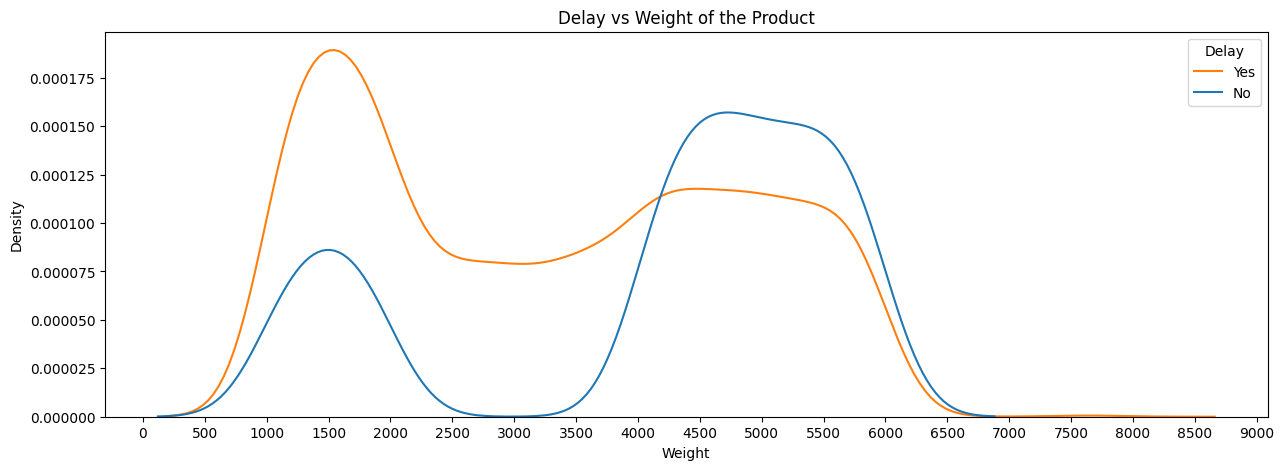

In [193]:
plt.figure(figsize=(15,5))
sns.kdeplot(data=df,x='Weight_in_gms',hue='Delay')
plt.legend(title='Delay',labels=['Yes','No'])
plt.title('Delay vs Weight of the Product')
plt.xticks(range(0,9500,500))
plt.xlabel('Weight')
plt.ylabel('Density')



---


### **Delay by Product Importance**

Text(0.5, 0, 'Importance')

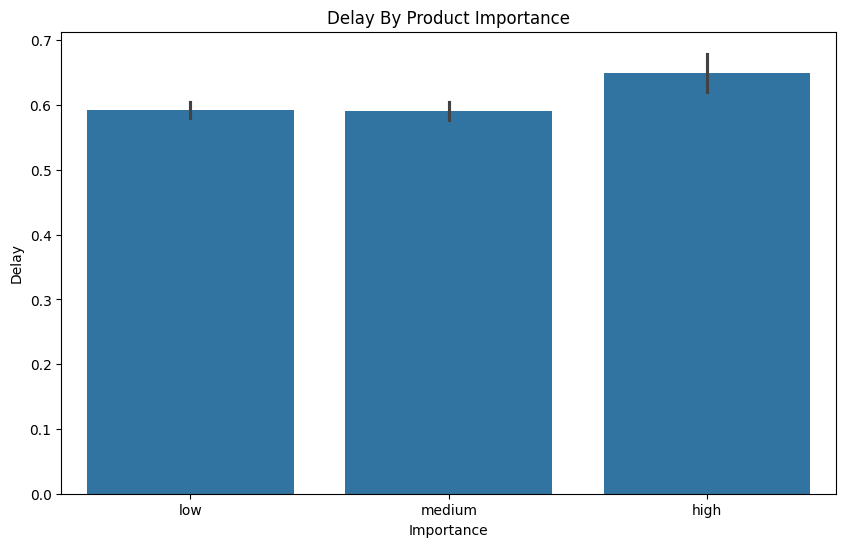

In [65]:
plt.figure(figsize=(10, 6))
sns.barplot(df,x='Product_importance',y='Delay')
# plt.legend(title='Delay',labels=['Yes','No'])
plt.title('Delay By Product Importance')
plt.ylabel('Delay')
plt.xlabel('Importance')

**High Importance Products Got Delayed the most with 65% while low and medium importance got delayed 60%**



---



In [66]:
df.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Delay'],
      dtype='object')

---
### Cost of Product

Text(0, 0.5, 'Discount')

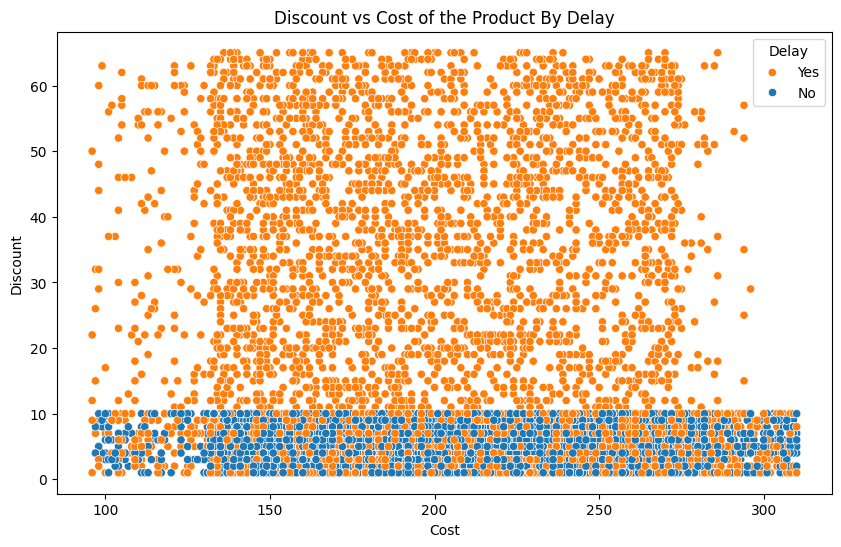

In [67]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Cost_of_the_Product',y='Discount_offered',data=df,hue='Delay')
plt.legend(title='Delay',labels=['Yes','No'])
plt.title('Discount vs Cost of the Product By Delay')
plt.xlabel('Cost')
plt.ylabel('Discount')

Text(0, 0.5, 'Density')

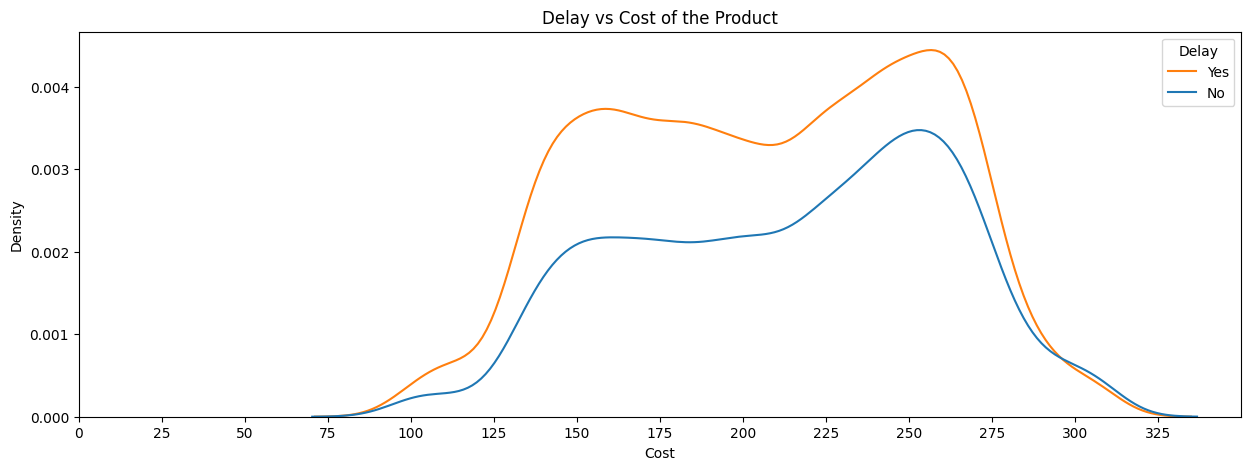

In [201]:
plt.figure(figsize=(15,5))
sns.kdeplot(data=df,x='Cost_of_the_Product',hue='Delay')
plt.legend(title='Delay',labels=['Yes','No'])
plt.title('Delay vs Cost of the Product')
plt.xticks(range(0,350,25))
plt.xlabel('Cost')
plt.ylabel('Density')

In [198]:
delay_cost=df.groupby('Cost_of_the_Product')['Delay'].mean().sort_values(ascending=False).reset_index()

Text(0, 0.5, 'Delay')

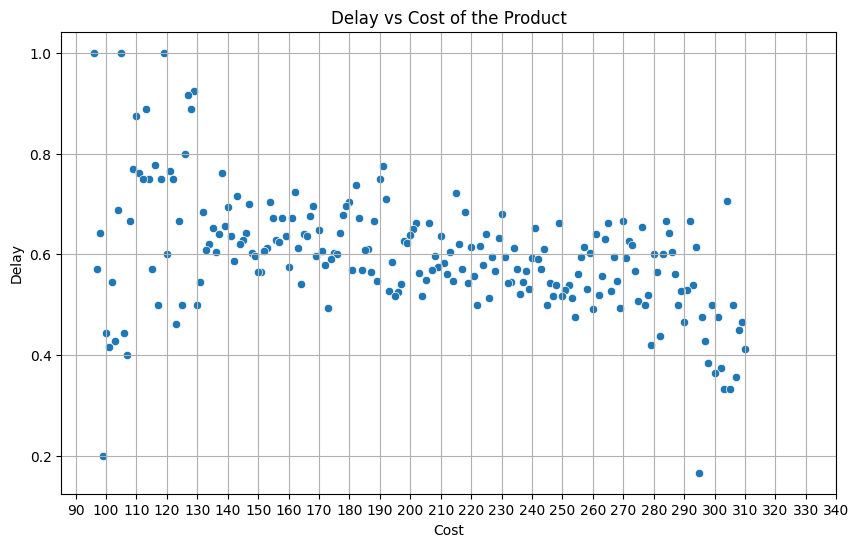

In [76]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Cost_of_the_Product',y='Delay',data=delay_cost)
plt.title('Delay vs Cost of the Product')
plt.xticks(range(90,350,10))
plt.grid(True)
plt.xlabel('Cost')
plt.ylabel('Delay')

**High Cost Products Has Lower Delay PCT%**

---


### Customer

In [88]:
customer = df.groupby('ID').agg({'Delay': 'mean',
'Customer_care_calls': 'sum',
'Customer_rating': 'mean',
'Prior_purchases': 'max'}).reset_index()
customer

,ID,Delay,Customer_care_calls,Customer_rating,Prior_purchases
0,1,1.0,4,2.0,3
1,2,1.0,4,5.0,2
2,3,1.0,2,2.0,4
3,4,1.0,3,3.0,4
4,5,1.0,2,2.0,3
...,...,...,...,...,...
10994,10995,1.0,4,1.0,5
10995,10996,0.0,4,1.0,5
10996,10997,0.0,5,4.0,5
10997,10998,0.0,5,2.0,6


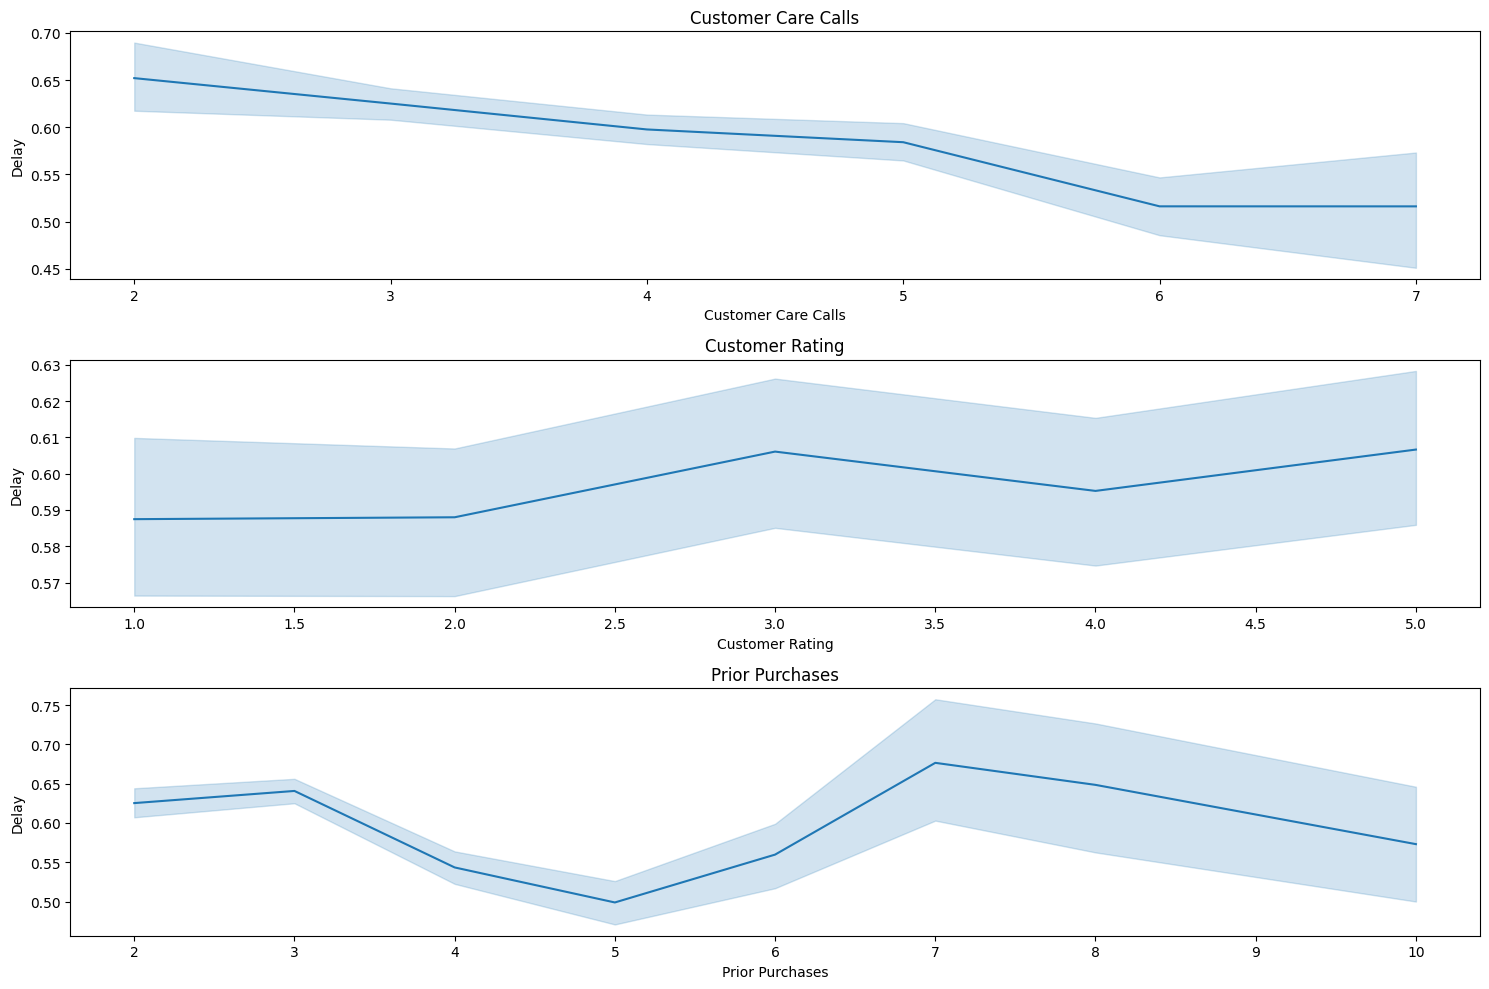

In [99]:
fig, ax = plt.subplots(3, 1, figsize=(15, 10))
sns.lineplot(data=customer,x='Customer_care_calls',y='Delay',ax=ax[0])
ax[0].set_title('Customer Care Calls')
ax[0].set_xlabel('Customer Care Calls')

sns.lineplot(data=customer,x='Customer_rating',y='Delay',ax=ax[1])
ax[1].set_title('Customer Rating')
ax[1].set_xlabel('Customer Rating')

sns.lineplot(data=customer,x='Prior_purchases',y='Delay',ax=ax[2])
ax[2].set_title('Prior Purchases')
ax[2].set_xlabel('Prior Purchases')

plt.tight_layout()
plt.show()




*   **Customer with 7+ Calls Get 12% Less Delay than Customers with 2 calls only**
*   **High Avg Customer Rating Get Higher Delayes**
* **Prior Purchase Goes from 63% delay for 2 prior purchases to 52% on 5 prior purchase then spikes at 7 prior purchase with 66% and goes down to 57% at 10 prior purchases**






---



### Revenue at Risk
> Total Delayed Cost vs Total On-time Costg

Text(0, 0.5, 'Total Cost')

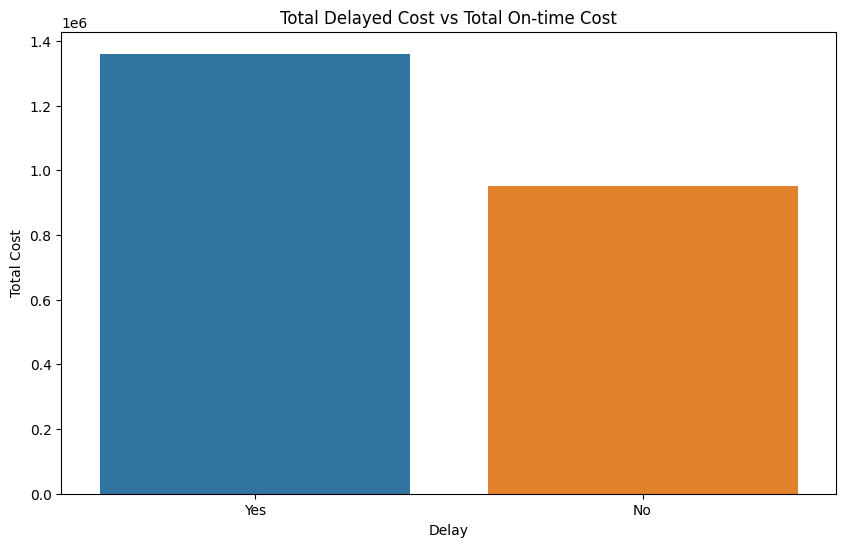

In [118]:
revenue_risk = df.groupby('Delay')['Cost_of_the_Product'].sum().sort_values(ascending=False).reset_index()
revenue_risk['Delay']= revenue_risk['Delay'].map({0:'No',1:'Yes'})
plt.figure(figsize=(10, 6))
sns.barplot(data=revenue_risk,x='Delay',y='Cost_of_the_Product',hue='Delay')
plt.title('Total Delayed Cost vs Total On-time Cost')
plt.ylabel('Total Cost')

In [117]:
revenue_risk

,Delay,Cost_of_the_Product
0,Yes,1360439
1,No,951516




*   **Delayed Items Cost Around 1.36m USD**
*   **on-time items cost around 950K USD**
* **Delayed Items cost 43% more than on-time items**





---



# Machine Learning Model

## Data Prep

In [128]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder


In [171]:

# Convert all text columns to numbers using Label Encoding
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

pred_df= df.drop(['ID'], axis=1)
X = pred_df.drop(['Delay'], axis=1) # All columns except 'Delay'
y = pred_df['Delay'] # Only 'Delay'

In [172]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Tuning

In [173]:
rf= RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Accuracy: 66.68%


In [174]:
# Quick combo 1: Focus on reducing overfitting
rf1 = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# Quick combo 2: More trees, balanced classes
rf2 = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    class_weight='balanced',
    max_features=0.3,  # Try 30% of features
    random_state=42,
    n_jobs=-1
)

# Quick combo 3: Shallow trees, many estimators
rf3 = RandomForestClassifier(
    n_estimators=1000,
    max_depth=8,  # Shallow trees
    min_samples_leaf=10,
    max_features='log2',
    random_state=42,
    n_jobs=-1
)

rf4 = RandomForestClassifier(
    n_estimators=1000,
    max_depth=5,
    min_samples_leaf=10,
    max_features='log2',
    random_state=42,
    n_jobs=-1
)


# Test each quickly
for i, model in enumerate([rf1, rf2, rf3, rf4], 1):
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"Model {i}: {score:.3f}")

Model 1: 0.691
Model 2: 0.691
Model 3: 0.694
Model 4: 0.690


In [176]:
rf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=8,
    max_features='log2',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Accuracy: 69.77%


## Feature Importance

               Feature  Importance
8     Discount_offered    0.436262
9        Weight_in_gms    0.351141
4  Cost_of_the_Product    0.076715
5      Prior_purchases    0.055775
2  Customer_care_calls    0.026236
3      Customer_rating    0.016090
0      Warehouse_block    0.014115
6   Product_importance    0.009745
1     Mode_of_Shipment    0.008397
7               Gender    0.005525


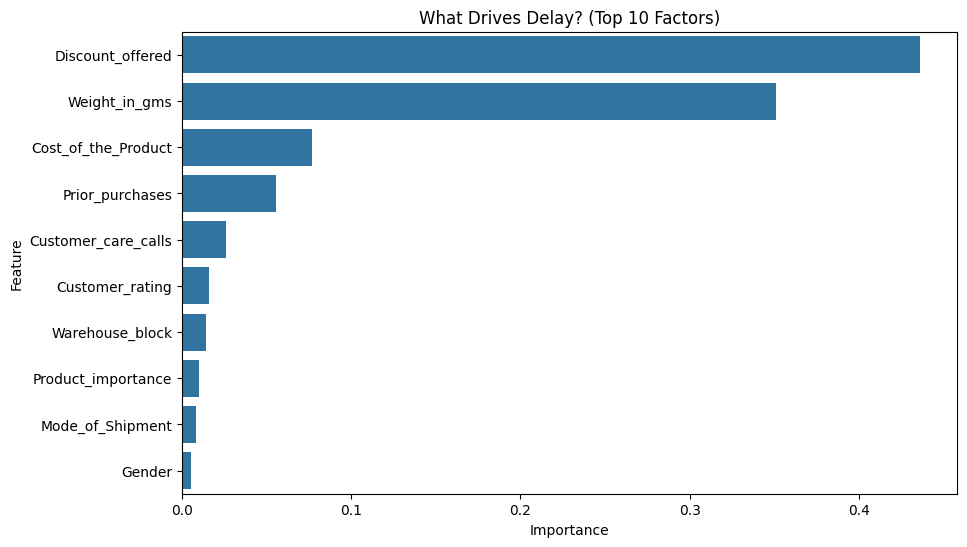

In [177]:
importances = rf.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title("What Drives Delay? (Top 10 Factors)")
plt.show()

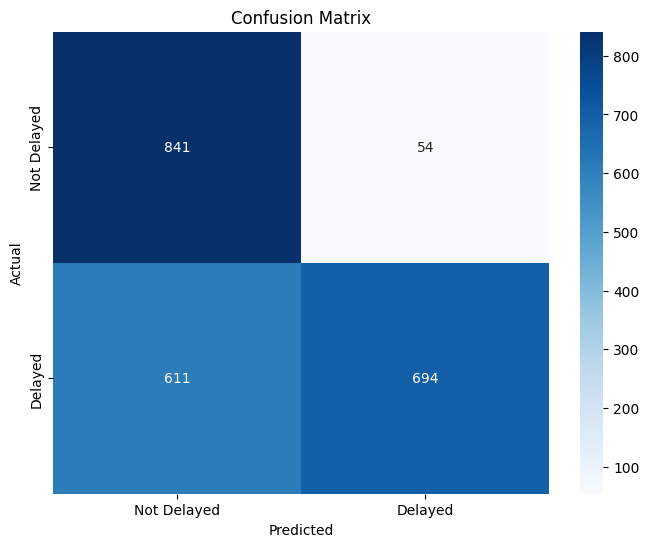

In [178]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Delayed', 'Delayed'],
            yticklabels=['Not Delayed', 'Delayed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



---

